In [1]:
import numpy as np
from gfsupg.solver import CartesianGeometry, FiniteElement1D, Scipy2DFEM
from gfsupg.solver import DeC, ImplicitEuler

from gfsupg.plotting import *

from gfsupg.problem import *

import time
import scipy.sparse as sp

import matplotlib.pyplot as plt

In [2]:

#problem.T_fin = 1.
order=2

FEM1Dx = FiniteElement1D(order-1,"gaussLobatto","gaussLobatto")
FEM1Dy = FiniteElement1D(order-1,"gaussLobatto","gaussLobatto")
dec = DeC(1,order,"gaussLobatto")
# dec = DeC(4,5,"gaussLobatto")


In [ ]:
# problem = SmoothVortexTestCase(is_long=False, pert_coeff=1e-3, pert_type="opt") #LinearAdvection("smooth_vortex_long")
# problem = StommelGyreTestCase(is_long=False, pert_coeff=1e-3, pert_type="num") #LinearAdvection("smooth_vortex_long")
problem = SourceVortexTestCase(is_long=True) #LinearAdvection("smooth_vortex_long")
#problem = CoriolisVortexTestCase(is_long=True)
problem = ObliqueTestCase()

In [4]:

Ns = np.array([20,20], dtype=np.int32)

geom = CartesianGeometry(problem.xL,problem.xR, Ns, problem.geometry_folder, BC=problem.BC)

In [5]:
FEM2D = Scipy2DFEM(geom,FEM1Dx, FEM1Dy, folder=problem.folderName)

Assembled matrices in 0.074 seconds


In [6]:
solver = ImplicitEuler(problem, FEM2D, dec, GF = False, stab = "SUPG", trick_second_der=False)

In [13]:
q, tt, comp_time, error , _  = solver.solve(CFL=1.0, with_error = True, save_sol = True)

CFL number = 1
Iteration 0002001, time 100.05000, max vars 0.292  0.281  1.000 ,  min vars -0.285  -0.285  1.000 
Simulation over in 65.29 seconds
Computing exact solution and error



In [14]:
print(error)


[0. 0. 0.]


In [15]:
tt.shape

(34,)

In [16]:
len(tt)

34

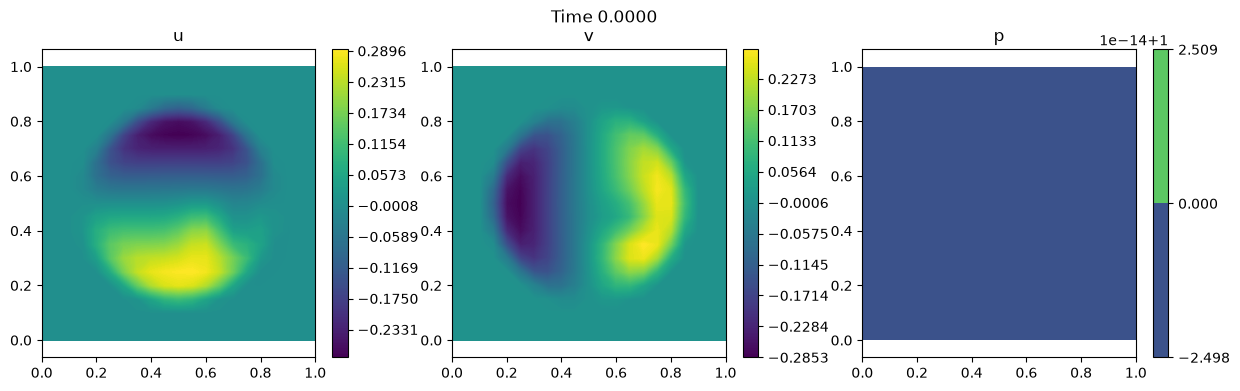

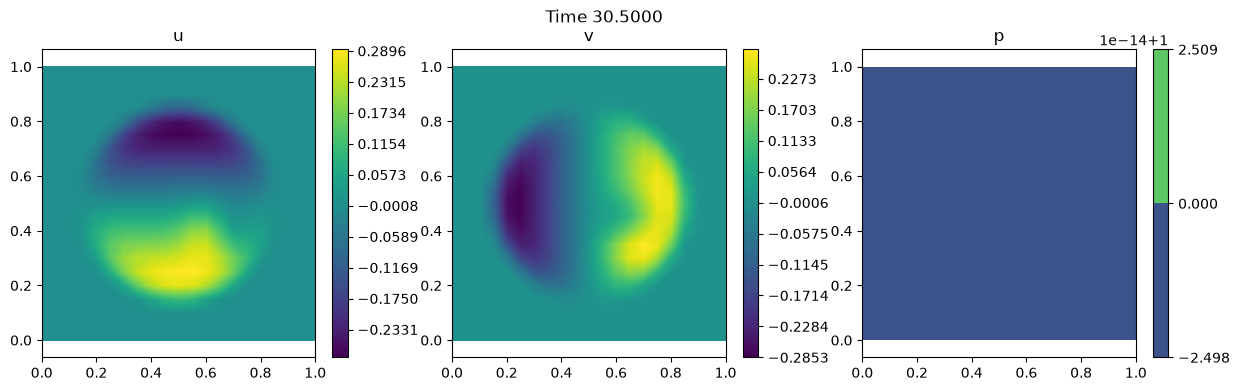

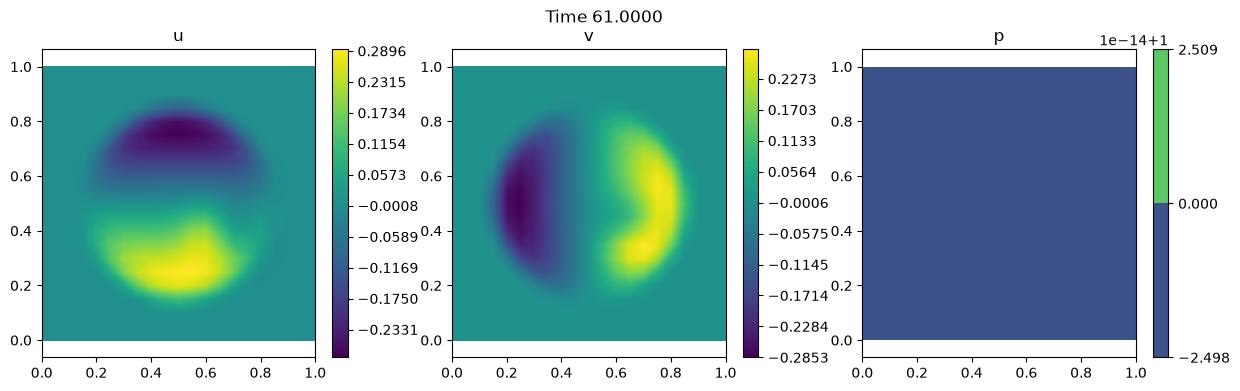

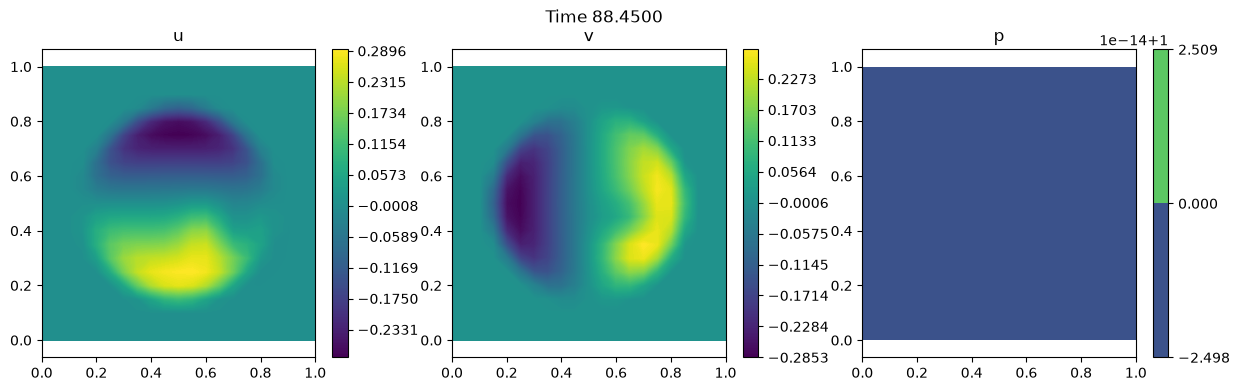

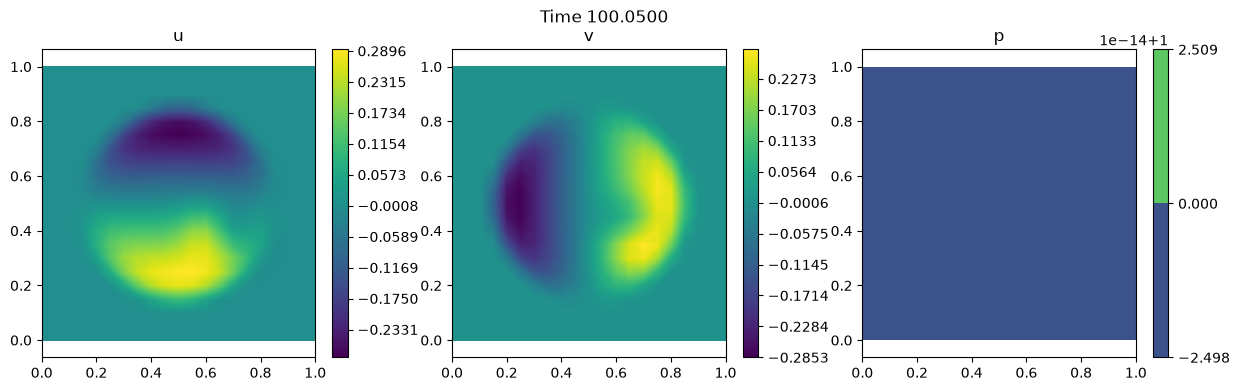

In [17]:
for it in [0,10,20,29, len(tt)-1]:
    t = tt[it]
    plot_all_sols(problem, FEM2D,q,it, t , 200)


In [19]:
from gfsupg.solver import Dirichlet_BC_set

In [20]:
if solver.problem.dirichlet is not None:
    dirichlet_BC = dict()
    for bc_item in solver.problem.dirichlet.keys():
        BC_values = dict()
        idxs = solver.FEM2D.dirichlet_indexes[bc_item]
        for var in solver.problem.dirichlet[bc_item]:
            BC_values[var] = solver.ic_vect[var][idxs]
        dirichlet_BC[bc_item] = Dirichlet_BC_set(idxs, BC_values)

else:
    dirichlet_BC = None

#Define big matrices
A, B = solver.build_whole_matrices(solver.stab_coeff, solver.geom.dx_min, dirichlet_BC)


In [26]:
solver.problem.dirichlet is None

True

In [21]:
A.todense()

matrix([[0.0025, 0.    , 0.    , ..., 0.    , 0.    , 0.    ],
        [0.    , 0.0025, 0.    , ..., 0.    , 0.    , 0.    ],
        [0.    , 0.    , 0.0025, ..., 0.    , 0.    , 0.    ],
        ...,
        [0.    , 0.    , 0.    , ..., 0.0025, 0.    , 0.    ],
        [0.    , 0.    , 0.    , ..., 0.    , 0.0025, 0.    ],
        [0.    , 0.    , 0.    , ..., 0.    , 0.    , 0.0025]],
       shape=(1323, 1323))

In [22]:
B.todense()

matrix([[ 0.001875,  0.000625,  0.      , ...,  0.      ,  0.      ,
          0.      ],
        [ 0.000625,  0.00125 ,  0.000625, ...,  0.      ,  0.      ,
          0.      ],
        [ 0.      ,  0.000625,  0.00125 , ...,  0.      ,  0.      ,
          0.      ],
        ...,
        [ 0.      ,  0.      ,  0.      , ...,  0.005   , -0.00125 ,
          0.      ],
        [ 0.      ,  0.      ,  0.      , ..., -0.00125 ,  0.005   ,
         -0.00125 ],
        [ 0.      ,  0.      ,  0.      , ...,  0.      , -0.00125 ,
          0.00375 ]], shape=(1323, 1323))